# 3d Optimiztion of GC design from 2d seed

Here we are going to set up the function that we will copy over to the main file. We want to make sure that the gradients are working

In [1]:
import autograd.numpy as npa
import numpy as np
import tidy3d as td
from autograd.tracer import getval
from autograd import value_and_grad
import matplotlib.pyplot as plt
import tidy3d.web as web
import json
import copy
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.fontset'] = 'cm'  # Use Computer Modern math fonts
mpl.rcParams['font.family'] = 'STIXGeneral'  # Use STIX fonts (similar to Computer Modern)
plt.rcParams.update({'font.size': 16})

In [2]:
# 3d specific parameters
taper_theta = npa.deg2rad(20)

# Material.
nInP = 3.13
nAir = 1.0

# Simulation wavelength.
wl = 1.55  # Central simulation wavelength (um).
bw = .15  # Simulation bandwidth (um).
n_wl = 51  # Number of wavelength points within the bandwidth.

#the parameters that kasra optimized
grating_period = .650 # period of the grating
etch_depth = 0.1 #etching depth in (um)
to_substrate = 1.210 #thickness of the substrate (um)
initial_fill_factor = 0.1 #fill factor initial for apodization
R = 0.03 #the coefficent for the apodization with units of (um^-1)
r0 = 6 #distance to the first tooth from the end of the waveguide (um)

# Geometric parameters.
w_thick = 0.27  # Waveguide thickness (um).
w_width = 0.55  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
border_buffer = 0.16 # buffer around the device
N_teeth = 15 # number of teeth in the grating

#fiber output permaters all initial
source_theta = npa.deg2rad(10.0) #angle of the fiber output 
mfd = 4 #mode fiber diameter
source_x = 11.5 #x position to the start of the first gap  
src_offset = 0.5  # Distance between the source focus and device (um).

# Material definition.
mat_InP = td.Medium(permittivity=nInP**2)  # Waveguide material.
mat_air = td.Medium(permittivity=nAir**2)  # SiO2 material.

#fabrication parameters
sidewall_angle = 0 #angle of the sidewall
dilation = 0 #dilation of the sidewalls

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = npa.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 2e-12

# Computational domain size.
pml_spacing = 0.6 * wl
inf_eff = 1000
min_steps_per_wvl = 20

#define the bounds for the parameters
widths_bounds = (0.05, 0.6)
r0_bounds = (4,6)
etch_depth_bounds = (0.05, 0.2)
to_substrate_bounds = (.8,2)

In [3]:
def projection_builder(widths_bounds=widths_bounds, 
    r0_bounds=r0_bounds, 
    etch_depth_bounds=etch_depth_bounds, 
    to_substrate_bounds=to_substrate_bounds,
    N_teeth=N_teeth
):
    """
    This function builds the projection and inverse projection functions for a given set of bounds.
    """
    maxes = npa.array([*([widths_bounds[1]]*(N_teeth*2+2)), r0_bounds[1], etch_depth_bounds[1], to_substrate_bounds[1]])
    mins = npa.array([*([widths_bounds[0]]*(N_teeth*2+2)), r0_bounds[0], etch_depth_bounds[0], to_substrate_bounds[0]])

    def project(params):
        return 0.5*(maxes-mins)*npa.tanh(params)+0.5*(maxes+mins)
    
    def inverse_project(params):
        return npa.arctanh((2*params-(maxes+mins))/(maxes-mins))
    
    return project, inverse_project

In [4]:
def get_centers(widths, r0):
    """
    This function takes in a list of widths and returns a list of centers.

    Args:
        widths (list): A list of widths.
        r0 (float): The radius that the grating starts at.

    Returns:
        list: A list of centers.
    """
    centers = []
    for i in range(len(widths)):
        centers.append(r0+npa.sum(widths[:i])+widths[i]/2)
    return centers

def get_tooth_arc(r,w_width=w_width,taper_theta=taper_theta,theta_div=150):
    """
    This resurns the xy values for the tooth arc
    """
    thetas = npa.linspace(taper_theta,-taper_theta,theta_div,endpoint=True)
    D = w_width/2/np.tan(taper_theta)
    xs = (D+r)*npa.cos(thetas)-D
    ys = (D+r)*npa.sin(thetas)
    return npa.column_stack((xs,ys))


In [ ]:
def make_grating_structure(
    widths,
    etch_depth=etch_depth,
    to_substrate=to_substrate,
    r0=r0,
    N_teeth=N_teeth,
    grating_period=grating_period,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
    fill=-1
):
    """
    This function makes the grating structure.
 
    Args:
        widths (list): A list of widths.
        etch_depth (float): The etching depth.
        to_substrate (float): The thickness of the substrate.
        r0 (float): The radius that the grating starts at.
        N_teeth (int): The number of teeth in the grating.
        sidewall_angle (float): The angle of the sidewall.
        dilation (float): The dilation of the sidewalls.
    """
    #get the centers of the teeth and gaps
    centers = get_centers(widths, r0)

    #untracked values
    dilation_untracked = float(getval(dilation))
    etch_depth_untracked = float(getval(etch_depth))

    #create the substrate
    substrate = td.Structure(
            geometry=td.Box.from_bounds((-inf_eff,-inf_eff,-inf_eff),(inf_eff,inf_eff,-to_substrate)),
            medium=mat_InP,
            name='substrate')

    #create the waveguide
    waveguide = td.Structure(
        geometry=td.Box.from_bounds((-inf_eff,-w_width/2,0),
                                    (0,w_width/2,w_thick)),
        medium=mat_InP,
        name='bottom_waveguide')
    
    #create taper 
    x_taper = npa.linspace(0, (r0+dilation+w_width/2/npa.tan(taper_theta))*npa.cos(taper_theta)-w_width/2/npa.tan(taper_theta), 500)
    y_taper = npa.linspace(w_width/2, (w_width/2/npa.tan(taper_theta)+r0+dilation)*npa.sin(taper_theta), 500)
    taper_vertices = npa.concatenate([
        npa.column_stack((x_taper[:-1], y_taper[:-1])),
        get_tooth_arc(r0+dilation),
        npa.column_stack((x_taper[:-1][::-1], -y_taper[:-1][::-1]))])
    
    top_taper = td.Structure(
        geometry=td.PolySlab(
        vertices=taper_vertices,
        axis=2,
        slab_bounds=(w_thick-etch_depth_untracked,w_thick)),
        medium=mat_InP,
        name='top_taper')

    bottom_taper = td.Structure(
        geometry=td.PolySlab(
        vertices=npa.array(taper_vertices),
        axis=2,
        slab_bounds=(0,w_thick-etch_depth_untracked)),
        medium=mat_InP,
        name='bottom_taper')

    #create the end waveguide
    end_arc = get_tooth_arc(centers[-1]-widths[-1]/2-dilation)
    end_vertices = npa.concatenate([
        end_arc,
        npa.column_stack((inf_eff,end_arc[-1,1])),
        npa.column_stack((inf_eff,end_arc[0,1])),
    ])
    end_waveguide = td.Structure(   
        geometry=td.PolySlab(
        vertices=end_vertices,
        axis=2,
        slab_bounds=(0,w_thick)),
        medium=mat_InP,
        name='top_end_waveguide')

    #get the centers of the teeth and gaps
    teeth = []
    teeth_low = []
    teeth_gap_low = []
    for i, (center, width) in enumerate(zip(centers, widths)):

        if i % 2 == 0:
            vertices = npa.concatenate([
                get_tooth_arc(center-width/2+dilation),
                get_tooth_arc(center+width/2-dilation)[::-1],
            ])
            if i > fill:
                tooth_geom_gap_low = td.PolySlab(
                    vertices=getval(vertices),
                    axis=2,
                    slab_bounds=(0,w_thick-etch_depth))
            else:
                tooth_geom_gap_low = td.PolySlab(
                    vertices=getval(vertices),
                    axis=2,
                    slab_bounds=(0,w_thick))
            teeth_gap_low.append(tooth_geom_gap_low)

        if i%2 == 1 and i != len(centers)-1:
            vertices = npa.concatenate([
                get_tooth_arc(center-width/2-dilation),
                get_tooth_arc(center+width/2+dilation)[::-1],
            ])
            tooth_geom = td.PolySlab(
                vertices=vertices,
                axis=2,
                slab_bounds=(w_thick-etch_depth_untracked,w_thick),
                sidewall_angle=sidewall_angle)
            teeth.append(tooth_geom)

            tooth_geom_low = td.PolySlab(
                vertices=getval(vertices),
                axis=2,
                slab_bounds=(0,w_thick-etch_depth_untracked))
            teeth_low.append(tooth_geom_low)
            
    teeth = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth),
            medium=mat_InP,
            name='teeth')
    teeth_low = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth_low),
            medium=mat_InP,
            name='teeth_low')
    teeth_gap_low = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth_gap_low),
            medium=mat_InP,
            name='teeth_gap_low')

    #define the minumum and maximum x and z bounds
    min_x = -border_buffer-pml_spacing
    max_x = border_buffer+pml_spacing+getval(centers[-1]+widths[-1]/2+dilation)
    min_y = getval(end_arc[-1,1])-pml_spacing
    max_y = getval(end_arc[0,1])+pml_spacing
    min_z = -border_buffer-pml_spacing-getval(to_substrate)
    max_z = w_thick+border_buffer+pml_spacing

    sim_box = td.Box.from_bounds(
        rmin=(min_x,min_y,min_z),
        rmax=(max_x,max_y,max_z),
    )

    structures = [substrate, waveguide, top_taper, bottom_taper, teeth, teeth_gap_low, teeth_low, end_waveguide]
    return structures, sim_box

In [6]:
def make_sim(
    widths,
    etch_depth=etch_depth,
    to_substrate=to_substrate,
    grating_period=grating_period,
    r0=r0,
    N_teeth=N_teeth,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
    source_x=source_x,
    source_theta=source_theta,
    mfd=mfd,
    src_offset=src_offset,
    include_field_monitor=False,
    freq=freq,
    freqw=freqw,
    freqs=freqs,
    run_time=run_time,
    pml_spacing=pml_spacing,
    min_steps_per_wvl=min_steps_per_wvl,
    fill=-1
):  

    """ 
    This function makes the simulation.
    """

    #get the structures
    structures,sim_box = make_grating_structure(widths,
                etch_depth=etch_depth,
                to_substrate=to_substrate,
                r0=r0,
                N_teeth=N_teeth,
                grating_period=grating_period,
                w_thick=w_thick,
                border_buffer=border_buffer,
                sidewall_angle=sidewall_angle,
                dilation=dilation,
                fill=fill)

    #define the gaussian beam source
    sources = [td.GaussianBeam(
        size=(2 * mfd, 2 * mfd, 0),
        center=[6.6, 0, w_thick+src_offset],
        source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
        angle_theta=source_theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
        waist_distance=-src_offset,
    )]

    #define the mode monitor
    monitors = [
        td.ModeMonitor(
        center=(-border_buffer, 0, w_thick / 2),
        size=(0, w_width*2, w_thick*4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=nInP),
        name="mode",
    )]

    #if we want to include the field monitor
    if include_field_monitor:
        monitors.append(
            td.FieldMonitor(
                center=(0, 0, 0),
                size=(inf_eff, inf_eff, inf_eff),
                freqs=freq,
                name="field",
            )
        )

    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
    )
    return sim

In [7]:
#open a json file and load the data
N_teeth = 6
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/3d_opt/stochastic_3D_opt_50nm.json', 'r') as f:
    data = json.load(f)

params0 = data['params'][-1]
widths = np.array([.3]*(N_teeth*2+2))#params0[:N_teeth*2+2]
r0 = params0[N_teeth*2+2]
etch_depth = .1#params0[N_teeth*2+3]
to_substrate = 1#params0[N_teeth*2+4]
dilation = 0


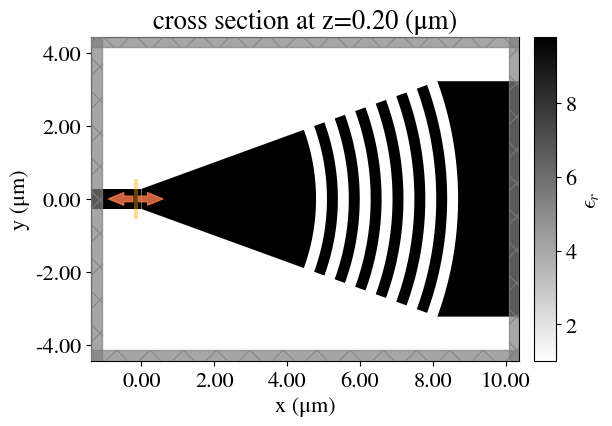

In [8]:
sim = make_sim(widths)
sim_2 = make_sim(widths,r0=r0,etch_depth=etch_depth,to_substrate=to_substrate,dilation=dilation)
fig, ax = plt.subplots(1,1)
#sim.plot_eps(y=0,ax=ax)
sim_2.plot_eps(z=.2,ax=ax)
plt.tight_layout()
plt.show()

In [10]:
paramsbad = np.hstack((widths,r0,etch_depth,to_substrate))
sim_data2,vals2 = objective2(paramsbad,6)

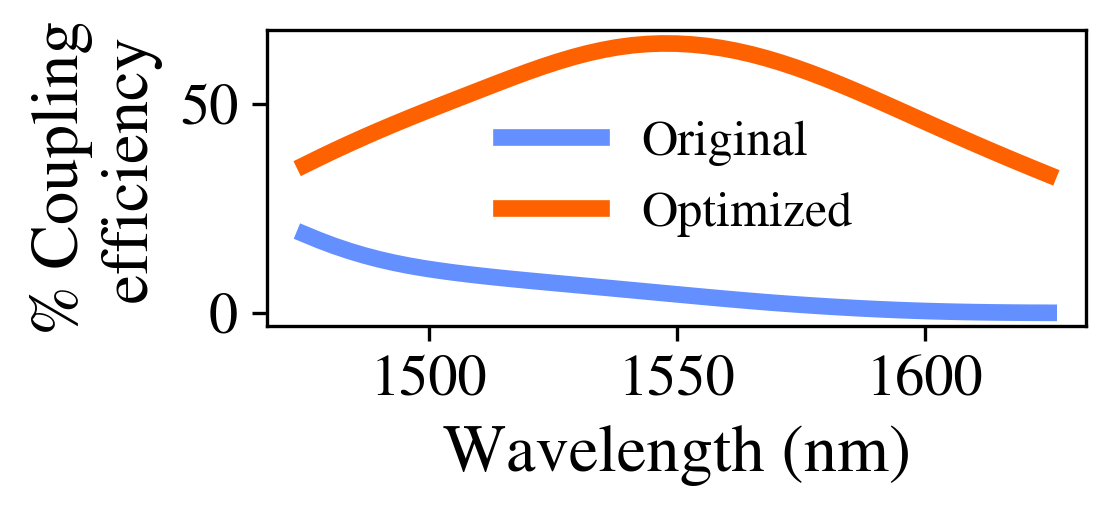

In [31]:
# print(vals2)
plt.figure(figsize=(4,2), dpi=300)
fig.patch.set_facecolor("none")   # whole figure
ax.set_facecolor("none")          # plot area (inside the axes)
plt.plot(wl_range*1000, vals2*100, color='#648fff', linewidth=4, label="Original")
plt.plot(wl_range*1000, val*100, color='#fe6100', linewidth=4, label="Optimized")
plt.xlabel('Wavelength (nm)', fontsize=16)
plt.ylabel('% Coupling\n efficiency', fontsize=16)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig('plot.png', transparent=False, bbox_inches='tight', facecolor='none', edgecolor='none')
plt.show()

# sim_data2.plot_field('field','E','abs^2',y=0)
# plt.show()

In [9]:
def get_coupling_efficiency(sim_data):
    """
    This function takes in the simulation data and returns the coupling efficiency.
    """
    return np.abs(sim_data["mode"].amps.sel(mode_index=0,direction="-").values)**2

def objective(params,N_teeth,dilation=0,path='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/tidy3d_output/temp.hdf5'):
    sim = make_sim(params[:N_teeth*2+2], 
        r0 = params[N_teeth*2+2],    
        etch_depth = params[N_teeth*2+3],
        to_substrate = params[N_teeth*2+4],
        dilation = dilation,
        min_steps_per_wvl=20,
        N_teeth=N_teeth)
    sim_data = web.run(sim, task_name="GC4um_3D_testing", folder_name="dominic", verbose=False, path=path)
    return get_coupling_efficiency(sim_data)[n_wl//2] 

def objective2(params,N_teeth,dilation=0,fill=-1,path='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/tidy3d_output/temp.hdf5'):
    sim = make_sim(params[:N_teeth*2+2], 
        r0 = params[N_teeth*2+2],    
        etch_depth = params[N_teeth*2+3],
        to_substrate = params[N_teeth*2+4],
        dilation = dilation,
        min_steps_per_wvl=20,
        N_teeth=N_teeth,
        include_field_monitor=True)
    sim_data = web.run(sim, task_name="GC4um_3D_testing", folder_name="dominic", verbose=False, path=path)
    return sim_data,get_coupling_efficiency(sim_data)

In [33]:
paramsbad = np.hstack((widths,r0,etch_depth,to_substrate))
sim_data,vals = objective2(paramsbad,6)

In [73]:
# 1. Run forward simulation and get mode amplitude
#sim_forward = make_sim(widths,r0=r0,etch_depth=etch_depth,to_substrate=to_substrate,dilation=dilation,include_field_monitor=True)
#sim_data_forward = web.run(sim_forward, task_name="forward", verbose=False)

# Get the mode amplitude at your frequency of interest
mode_amp = sim_data_forward["mode"].amps.sel(mode_index=0, direction="-").isel(f=n_wl//2)
# mode_amp is complex, shape: (f,) for multiple frequencies

# 2. Create adjoint source - ModeSource at the same location as ModeMonitor
# The adjoint source amplitude is the complex conjugate of the forward amplitude
adjoint_source = td.ModeSource(
    center=(-border_buffer, 0, w_thick / 2),  # Same as ModeMonitor center
    size=(0, w_width*2, w_thick*4),           # Same as ModeMonitor size
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw, amplitude=np.abs(1j*mode_amp), phase=np.angle(1j*mode_amp)),
    mode_spec=td.ModeSpec(num_modes=1, target_neff=nInP),  # Same mode spec
    mode_index=0,
    direction="+",  # Opposite direction! Forward was "-", adjoint is "+"
    # The amplitude will be set by Tidy3D based on the mode profile
    # You may need to scale it by conj(mode_amp) if Tidy3D doesn't do this automatically
)

# 3. Create adjoint simulation (same geometry, different source)
sim_adjoint = sim_forward.copy(update=dict(
    sources=[adjoint_source],  # Replace forward source with adjoint source
))

sim_data_adjoint = web.run(sim_adjoint, task_name="adjoint", verbose=False)

In [74]:
# Select frequency index (set this beforehand)
freq_idx = 0  # Central frequency

# Get forward fields at design region
field_data_forward = sim_data_forward["field"]
Ex_forward = field_data_forward.Ex.isel(f=freq_idx).values
Ey_forward = field_data_forward.Ey.isel(f=freq_idx).values
Ez_forward = field_data_forward.Ez.isel(f=freq_idx).values

# Get adjoint fields at design region
field_data_adjoint = sim_data_adjoint["field"]
Ex_adjoint = field_data_adjoint.Ex.isel(f=freq_idx).values
Ey_adjoint = field_data_adjoint.Ey.isel(f=freq_idx).values
Ez_adjoint = field_data_adjoint.Ez.isel(f=freq_idx).values

# Combine into vector form: E = [Ex, Ey, Ez]
E_forward = np.stack([Ex_forward, Ey_forward, Ez_forward], axis=-1)  # Shape: (x, y, z, 3)
E_adjoint = np.stack([Ex_adjoint, Ey_adjoint, Ez_adjoint], axis=-1)  # Shape: (x, y, z, 3)

# Compute dj/depsilon = -Re(E_forward * conj(E_adjoint))
dj_deps = -np.real(E_forward * np.conj(E_adjoint))  # Shape: (x, y, z, 3)

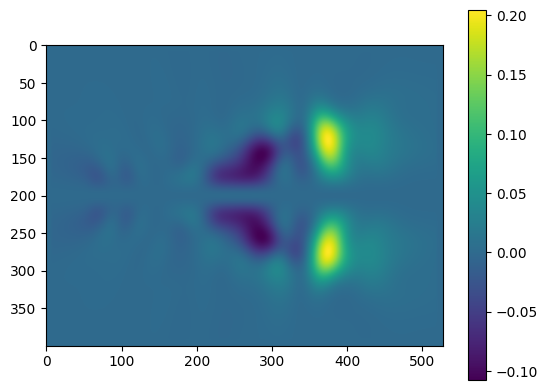

In [77]:
plt.imshow(dj_deps[:,:,118//2+5,0].T)
plt.colorbar()

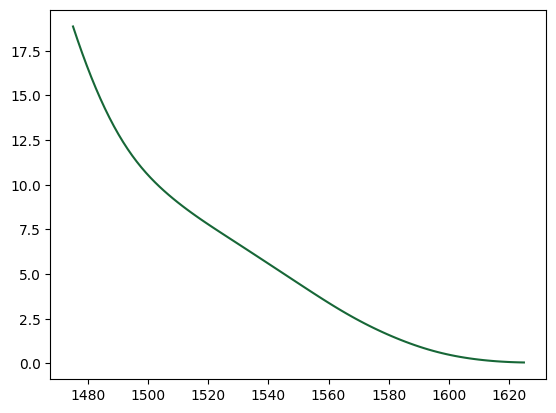

In [34]:
plt.plot(wl_range*1000,vals*100)
plt.show()

In [11]:
#open a json file and load the data
N_teeth = 6
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/3d_opt/stochastic_3D_opt_50nm.json', 'r') as f:
    data = json.load(f)

params0 = data['params'][-1]
widths = params0[:N_teeth*2+2]
r0 = params0[N_teeth*2+2]
etch_depth = params0[N_teeth*2+3]
to_substrate = params0[N_teeth*2+4]
sim_data,val = objective2(params0,6)


[0.35442636 0.37195342 0.38899412 0.40551462 0.42152391 0.43705711
 0.45215354 0.46685506 0.48122385 0.49534469 0.50931125 0.52321431
 0.53708072 0.55086047 0.56442165 0.57757217 0.59008699 0.60175344
 0.61237218 0.62176071 0.62975316 0.63620039 0.64099227 0.64406496
 0.64541115 0.64506404 0.64307275 0.63949029 0.63436107 0.62772505
 0.61964646 0.61021167 0.5995381  0.58775876 0.5750125  0.56142202
 0.54710666 0.53217942 0.51677456 0.50103241 0.48509041 0.46907918
 0.45309262 0.43719439 0.421431   0.40583064 0.39043078 0.3752567
 0.36032912 0.34563087 0.33111195]


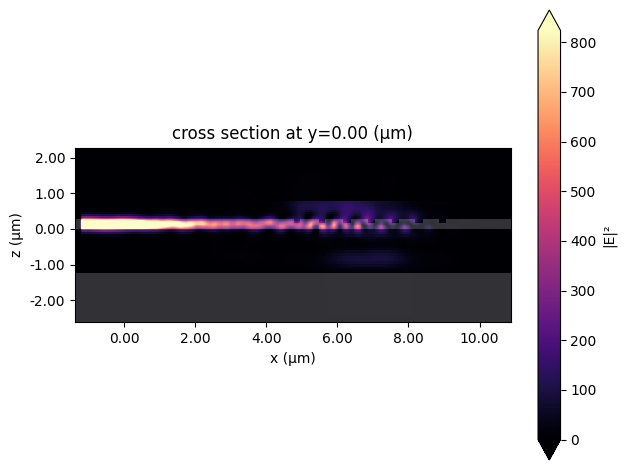

In [49]:
print(val)
sim_data.plot_field('field','E','abs^2',y=0)
plt.show()


6


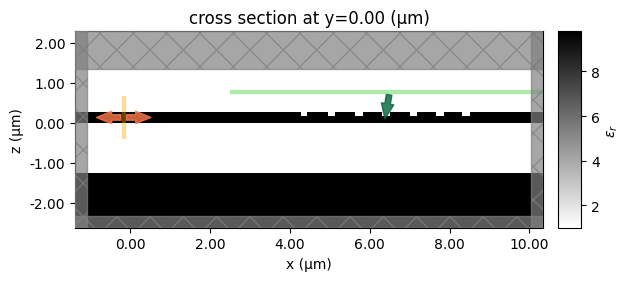

0.5590490018015324


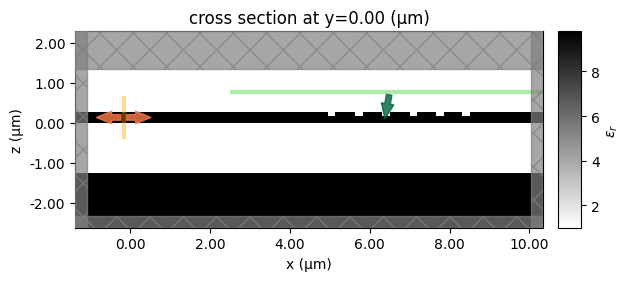

0.5590490018015324


ValueError: x and y must have same first dimension, but have shapes (7,) and (11,)

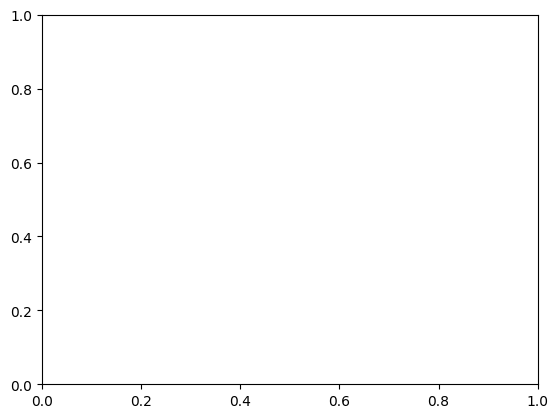

In [84]:
fills = [-1,0,2,4,6,8,10]
#values = []
print(r0)
for fill in fills[5:]:
    params0d = copy.deepcopy(params0)
    params0d[N_teeth*2+2] = 1
    objective(params0d,11,fill=fill)
    values.append(value)
    print(value)
plt.plot(fills,values)
plt.show()

In [13]:
N_teeth = 6
with open('/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_4um_3d/data/2d_opt/stochastic_opt_50nm_6teeth.json', 'r') as f:
    data = json.load(f)

params0 = data['params'][-1]
params0[N_teeth*2+2] += 3.8
print(params0[N_teeth*2+2])

4.810048673313407


In [14]:
sim_data,val = objective2(params0,N_teeth)

<Axes: title={'center': 'cross section at z=0.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

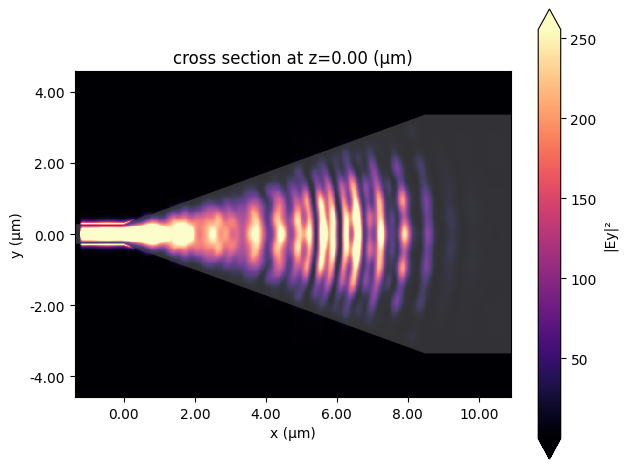

In [101]:
sim_data.plot_field('field','Ey','abs^2',z=0)

In [102]:
print(val)

0.6392338595096213


In [103]:
print(params0[N_teeth*2+2])

4.810048673313407


In [106]:
arr = np.array([0.14771477935473476,
      0.5338900310277187,
      0.18948849007479804,
      0.508549914353448,
      0.20825065755338473,
      0.48398207905520885,
      0.20267377453291296,
      0.46985602226123135,
      0.20255204097919072,
      0.45449450935917823,
      0.21308537493039204,
      0.4498343206072378,
      0.19455272084657219,
      0.43978901044837904,
      4.792437559427001,
      0.1140556478380534,
      1.2480988195732152
    ])

In [109]:
gps = arr[0:6*2+2:2]+arr[1:6*2+2:2]
print(gps)

[0.68160481 0.6980384  0.69223274 0.6725298  0.65704655 0.6629197
 0.63434173]


In [110]:
arr[1:6*2+2:2]/gps

array([0.78328384, 0.72854145, 0.69916092, 0.69863971, 0.69172345,
       0.67856533, 0.69329982])